In [50]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick 
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')

# Parameters set for more clear visuals
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

%matplotlib inline

In [2]:
df1 = pd.read_csv('data/Unemployment in India.csv')
df2 = pd.read_csv('data/Unemployment_Rate_upto_11_2020.csv')

In [3]:
df1

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df2

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.740
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.740
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.740
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.740
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.740
...,...,...,...,...,...,...,...,...,...
262,West Bengal,30-06-2020,M,7.29,30726310,40.39,East,22.9868,87.855
263,West Bengal,31-07-2020,M,6.83,35372506,46.17,East,22.9868,87.855
264,West Bengal,31-08-2020,M,14.87,33298644,47.48,East,22.9868,87.855
265,West Bengal,30-09-2020,M,9.35,35707239,47.73,East,22.9868,87.855


In [5]:
print("Dataset1 shape:", df1.shape)
print("Dataset2 shape:", df2.shape)

Dataset1 shape: (768, 7)
Dataset2 shape: (267, 9)


### clean Dataset 1

In [6]:
df1.columns = df1.columns.str.strip()

In [7]:
df1.dropna(inplace=True)

In [8]:
df1['Date'] = pd.to_datetime(df1['Date'].str.strip(), format='%d-%m-%Y')

In [9]:
df1

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,2020-02-29,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban


In [62]:
df1.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}, inplace=True)

In [63]:
print(df1.head())

           Region       Date Frequency  Unemployment_Rate    Employed  \
0  Andhra Pradesh 2019-05-31   Monthly               3.65  11999139.0   
1  Andhra Pradesh 2019-06-30   Monthly               3.05  11755881.0   
2  Andhra Pradesh 2019-07-31   Monthly               3.75  12086707.0   
3  Andhra Pradesh 2019-08-31   Monthly               3.32  12285693.0   
4  Andhra Pradesh 2019-09-30   Monthly               5.17  12256762.0   

   Labour_Participation   Area  
0                 43.24  Rural  
1                 42.05  Rural  
2                 43.50  Rural  
3                 43.97  Rural  
4                 44.68  Rural  


### clean Dataset 2

In [12]:
df2.columns = df2.columns.str.strip()
df2.dropna(inplace = True)

In [13]:
df2['Date'] = pd.to_datetime(df2['Date'].str.strip(), format='%d-%m-%Y')

In [14]:
df2.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Partocipation_Rate',
    'Region.1': 'Zone'
}, inplace = True)

In [15]:
print(df2.head())

           Region       Date Frequency  Unemployment_Rate  Employed  \
0  Andhra Pradesh 2020-01-31         M               5.48  16635535   
1  Andhra Pradesh 2020-02-29         M               5.83  16545652   
2  Andhra Pradesh 2020-03-31         M               5.79  15881197   
3  Andhra Pradesh 2020-04-30         M              20.51  11336911   
4  Andhra Pradesh 2020-05-31         M              17.43  12988845   

   Labour_Partocipation_Rate   Zone  longitude  latitude  
0                      41.02  South    15.9129     79.74  
1                      40.90  South    15.9129     79.74  
2                      39.18  South    15.9129     79.74  
3                      33.10  South    15.9129     79.74  
4                      36.46  South    15.9129     79.74  


### Dataset 1 summary

In [16]:
print(df1.describe().round(2))

                                Date  Unemployment_Rate  Estimated Employed  \
count                            740             740.00              740.00   
mean   2019-12-12 18:36:58.378378496              11.79          7204460.03   
min              2019-05-31 00:00:00               0.00            49420.00   
25%              2019-08-31 00:00:00               4.66          1190404.50   
50%              2019-11-30 00:00:00               8.35          4744178.50   
75%              2020-03-31 00:00:00              15.89         11275489.50   
max              2020-06-30 00:00:00              76.74         45777509.00   
std                              NaN              10.72          8087988.43   

       Labour_Participation  
count                740.00  
mean                  42.63  
min                   13.33  
25%                   38.06  
50%                   41.16  
75%                   45.50  
max                   72.57  
std                    8.11  


In [17]:
print("Regions covered:" , df1['Region'].nunique())
print("Date range:", df2['Date'].min().date(), "to", df1['Date'].max().date())
print("Area types:", df1['Area'].unique())

Regions covered: 28
Date range: 2020-01-31 to 2020-06-30
Area types: ['Rural' 'Urban']


### Dataset 2 summary

In [18]:
print(df2.describe().round(2))

                                Date  Unemployment_Rate     Employed  \
count                            267             267.00       267.00   
mean   2020-06-16 09:15:30.337078528              12.24  13962105.72   
min              2020-01-31 00:00:00               0.50    117542.00   
25%              2020-03-31 00:00:00               4.84   2838930.50   
50%              2020-06-30 00:00:00               9.65   9732417.00   
75%              2020-08-31 00:00:00              16.76  21878686.00   
max              2020-10-31 00:00:00              75.85  59433759.00   
std                              NaN              10.80  13366318.36   

       Labour_Partocipation_Rate  longitude  latitude  
count                     267.00     267.00    267.00  
mean                       41.68      22.83     80.53  
min                        16.77      10.85     71.19  
25%                        37.26      18.11     76.09  
50%                        40.39      23.61     79.02  
75%            

In [19]:
print("Date range:", df2['Date'].min().date(), "to", df2['Date'].max().date())
print("Zone:", df2['Zone'].unique())

Date range: 2020-01-31 to 2020-10-31
Zone: ['South' 'Northeast' 'East' 'West' 'North']


### Unemployment Trend Over Time

In [20]:
monthly_trend = df2.groupby('Date')['Unemployment_Rate'].mean().reset_index()

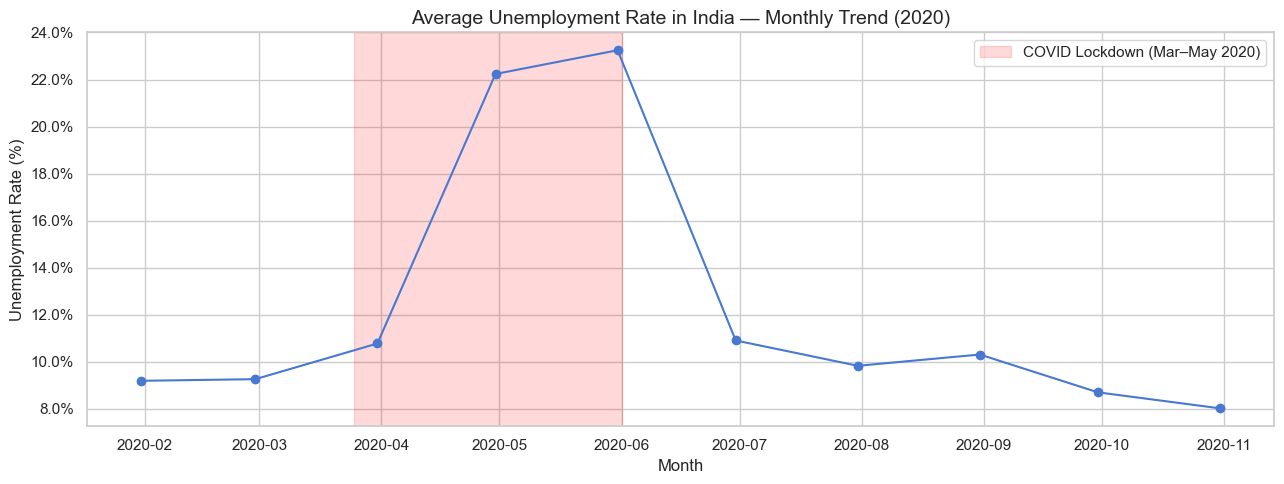


  Unemployment rate spiked sharply during COVID-19 lockdown(March-May 2020),
     peaking above 20% before gradually recovering. 


In [32]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_trend['Date'], monthly_trend['Unemployment_Rate'],
        marker='o', markersize=6)
ax.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-06-01'),
           alpha=0.15, color='red', label='COVID Lockdown (Mar–May 2020)')

ax.set_title("Average Unemployment Rate in India — Monthly Trend (2020)")
ax.set_xlabel("Month")
ax.set_ylabel("Unemployment Rate (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.savefig('trend_over_time.png', dpi=150)
plt.show()

print("\n  Unemployment rate spiked sharply during COVID-19 lockdown(March-May 2020),")
print("     peaking above 20% before gradually recovering. ")

### Rural Vs Urban Uneployment

In [35]:
rural = df1[df1['Area'] == 'Rural'].groupby('Date')['Unemployment_Rate'].mean()
urban = df1[df1['Area'] == 'Urban'].groupby('Date')['Unemployment_Rate'].mean()

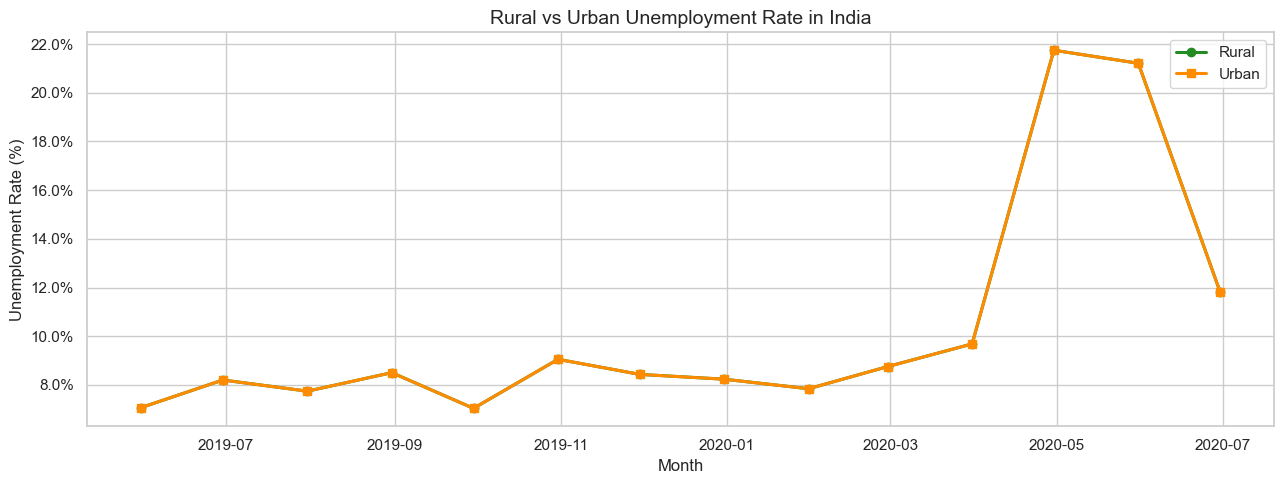


  Urban unemployment is consistently higher than rural.
  The gap widens significantly during the COVID lockdown period


In [40]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(rural.index, rural.values, label='Rural', marker='o', color='forestgreen', linewidth=2.2)
ax.plot(rural.index, rural.values, label='Urban', marker='s', color='darkorange', linewidth=2.2)

ax.set_title("Rural vs Urban Unemployment Rate in India")
ax.set_xlabel("Month")
ax.set_ylabel("Unemployment Rate (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.savefig('rural_vs_urban.png', dpi=150)
plt.show()

print("\n  Urban unemployment is consistently higher than rural.")
print("  The gap widens significantly during the COVID lockdown period")

### Top 10 states by Unemployment

In [43]:
state_avg = df1.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

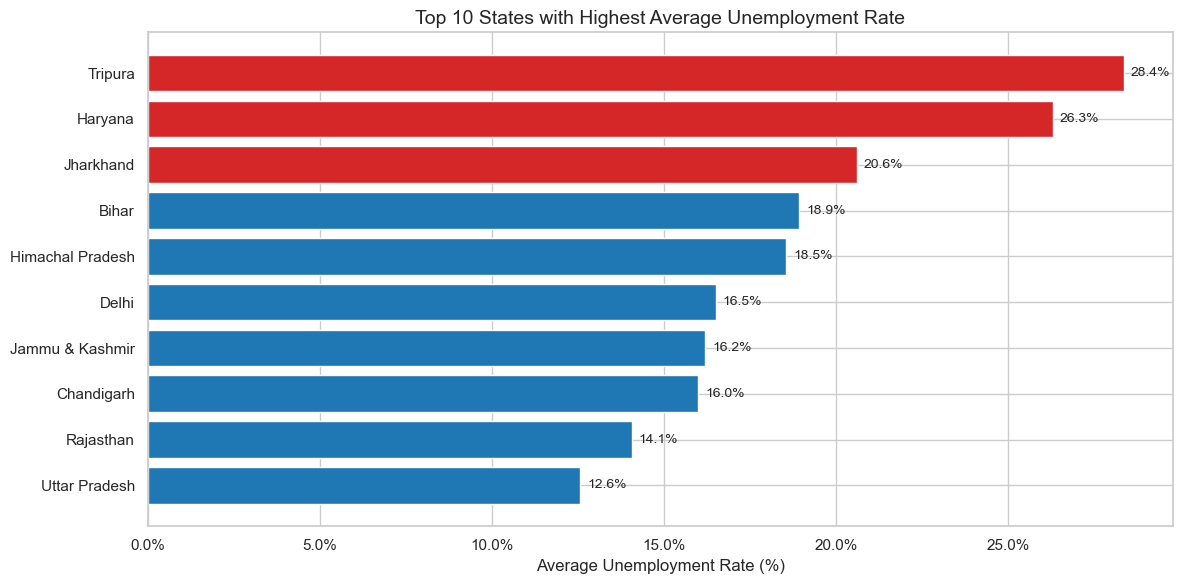

In [44]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#d62728' if i < 3 else '#1f77b4' for i in range(len(state_avg[:10]))]
bars = ax.barh(state_avg[:10].index[::-1], state_avg[:10].values[::-1], color=colors[::-1])

ax.set_title("Top 10 States with Highest Average Unemployment Rate")
ax.set_xlabel("Average Unemployment Rate (%)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%', va = 'center', fontsize=10)
    
plt.tight_layout()
plt.savefig('top_states.png', dpi = 150)
plt.show()

### COVID - 19 Impact Analysis

In [45]:
lockdown_date = pd.Timestamp('2020-03-25')

pre_covid = df2[df2['Date'] < lockdown_date]['Unemployment_Rate'].mean()
post_covid = df2[df2['Date'] >= lockdown_date]['Unemployment_Rate'].mean()

In [46]:
print(f"\nAverage Unemployment BEFORE lockdown : {pre_covid:.2f}%")
print(f"Average Unemployment AFTER lockdown  : {post_covid:.2f}%")
print(f"Increase  : +{post_covid - pre_covid:.2f} percentage points")


Average Unemployment BEFORE lockdown : 9.23%
Average Unemployment AFTER lockdown  : 12.96%
Increase  : +3.73 percentage points


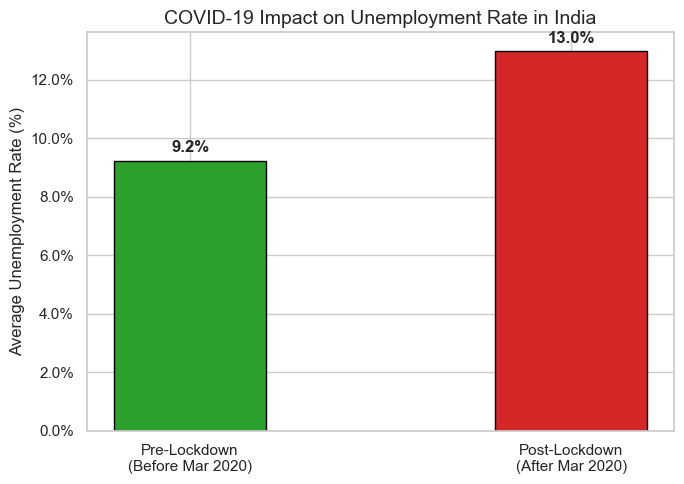

In [47]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ['Pre-Lockdown\n(Before Mar 2020)', 'Post-Lockdown\n(After Mar 2020)'],
    [pre_covid, post_covid],
    color=['#2ca02c', '#d62728'], width=0.4, edgecolor='black'
)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.3,
            f'{height:.1f}%', ha='center', fontsize=12, fontweight='bold')
    
ax.set_title("COVID-19 Impact on Unemployment Rate in India")
ax.set_ylabel("Average Unemployment Rate (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig('covid_impact.png', dpi = 150)
plt.show()

### Zone-Wise Unemployment

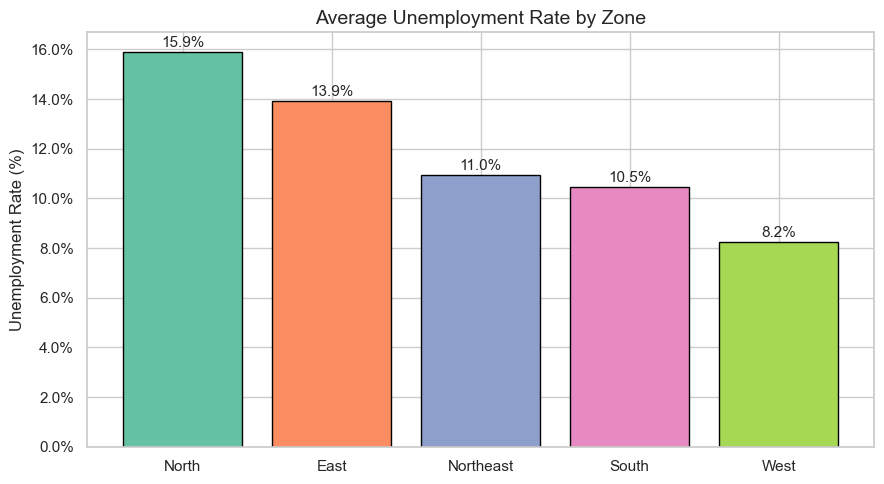


 Northeast and East zones show higher unemployment rates
   compared to South and West zones.


In [48]:
zone_avg = df2.groupby('Zone')['Unemployment_Rate'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
palette = sns.color_palette("Set2", len(zone_avg))
bars = ax.bar(zone_avg.index, zone_avg.values, color=palette, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.2,
            f'{height:.1f}%', ha='center', fontsize=11)

ax.set_title("Average Unemployment Rate by Zone")
ax.set_ylabel("Unemployment Rate (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig('zone_comparison.png', dpi=150)
plt.show()

print("\n Northeast and East zones show higher unemployment rates")
print("   compared to South and West zones.")


### Geographic Map (Interactive)

In [54]:
latest_date = df2['Date'].max()
latest_df = df2[df2['Date'] == latest_date].copy()

# Fix: lattitude and longitude are swapped in the dataset
latest_df = latest_df.rename(columns={'latitude': 'longitude', 'longitude': 'latitude'})

fig = px.scatter_geo(
    latest_df,
    lat='latitude',
    lon='longitude',
    color='Unemployment_Rate',
    hover_name='Region',
    hover_data={'Unemployment_Rate': ':.1f', 'Zone': True, 'latitude': False, 'longitude': False},
    size='Unemployment_Rate',
    size_max=45,
    color_continuous_scale='RdYlGn_r',
    title=f'Unemployment Rate by State — {latest_date.strftime("%B %Y")}',
    labels={'Unemployment_Rate': 'Unemployment Rate (%)'}
)

fig.update_geos(
    visible=False,
    showcountries=True, countrycolor='gray',
    showland=True, landcolor='#f0f0f0',
    showocean=True, oceancolor='#d0e8f5',
    showcoastlines=True, coastlinecolor='gray',
    lataxis_range=[5, 40],
    lonaxis_range=[65, 100]
)

fig.update_layout(
    coloraxis_colorbar=dict(title='Rate (%)'),
    margin=dict(l=0, r=0, t=40, b=0),
    geo=dict(projection_type='mercator')
)

fig.show()
fig.write_html('india_unemployment_map.html')
print("Map saved ")

Map saved 


In [57]:
df1

,Region,Date,Frequency,Unemployment_Rate,Estimated Employed,Labour_Participation,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,2020-02-29,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban


### Correlation Heatmap

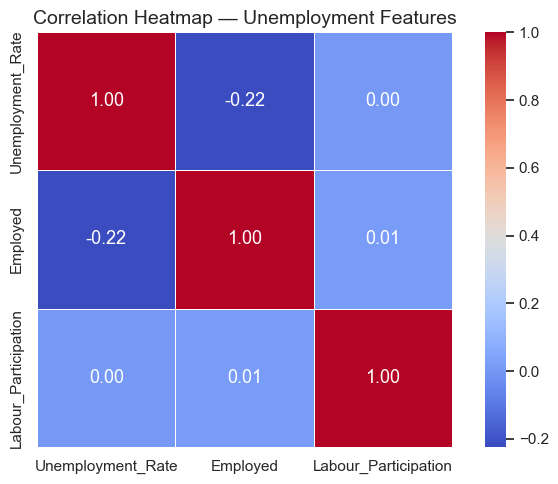


 Labour Participation Rate and Unemployment Rate show a positive correlation.
   As more people enter the workforce, measured unemployment also rises.


In [65]:
corr = df1[['Unemployment_Rate', 'Employed', 'Labour_Participation']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, ax=ax, annot_kws={'size': 13})
ax.set_title("Correlation Heatmap — Unemployment Features")
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("\n Labour Participation Rate and Unemployment Rate show a positive correlation.")
print("   As more people enter the workforce, measured unemployment also rises.")
